# Univariate Linear Regression and Gradient Descent



**Univariate Linear Regression** is a statistical method used to model the relationship between a single independent variable (feature) and a dependent variable (target) using a linear equation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
np.linspace(0,10,200)

array([ 0.        ,  0.05025126,  0.10050251,  0.15075377,  0.20100503,
        0.25125628,  0.30150754,  0.35175879,  0.40201005,  0.45226131,
        0.50251256,  0.55276382,  0.60301508,  0.65326633,  0.70351759,
        0.75376884,  0.8040201 ,  0.85427136,  0.90452261,  0.95477387,
        1.00502513,  1.05527638,  1.10552764,  1.15577889,  1.20603015,
        1.25628141,  1.30653266,  1.35678392,  1.40703518,  1.45728643,
        1.50753769,  1.55778894,  1.6080402 ,  1.65829146,  1.70854271,
        1.75879397,  1.80904523,  1.85929648,  1.90954774,  1.95979899,
        2.01005025,  2.06030151,  2.11055276,  2.16080402,  2.21105528,
        2.26130653,  2.31155779,  2.36180905,  2.4120603 ,  2.46231156,
        2.51256281,  2.56281407,  2.61306533,  2.66331658,  2.71356784,
        2.7638191 ,  2.81407035,  2.86432161,  2.91457286,  2.96482412,
        3.01507538,  3.06532663,  3.11557789,  3.16582915,  3.2160804 ,
        3.26633166,  3.31658291,  3.36683417,  3.41708543,  3.46

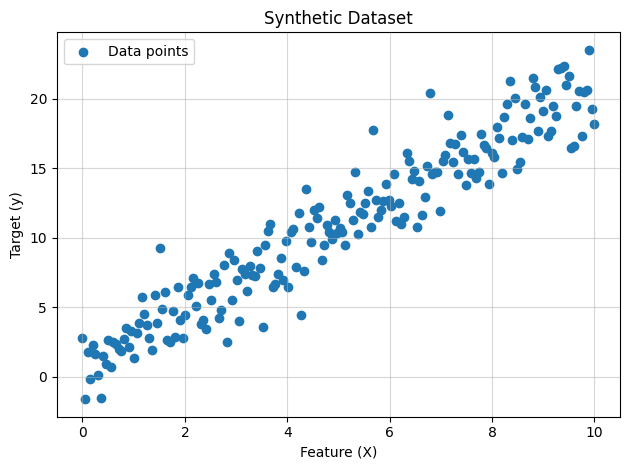

In [3]:
# Create a synthetic dataset with one feature and one target variable
X = np.linspace(0, 10, 200)
y = 2 * X + 1 + np.random.normal(0, 2, size=X.shape)
plt.scatter(X, y, label="Data points") 
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)") 
plt.title("Synthetic Dataset")
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [4]:
# Size of the Dataset
print(f"Size of X: {X.size}, Size of y: {y.size}")
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

Size of X: 200, Size of y: 200
Shape of X: (200,), Shape of y: (200,)


In [5]:
# Usually, X should be a 2D array for linear regression
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

Shape of X: (200, 1), Shape of y: (200, 1)


In [6]:
# !pip install scikit-learn

In [7]:
# Let's scale the features for better convergence
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.transform(y)

In [8]:
y_scaled.min()

np.float64(-2.280408437230236)

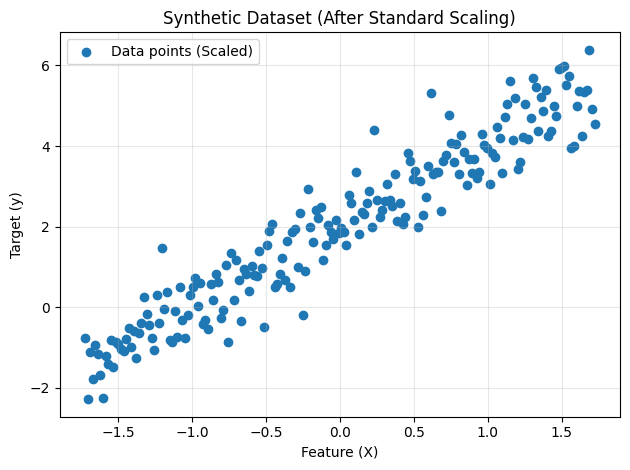

In [9]:
plt.scatter(X_scaled, y_scaled, label="Data points (Scaled)")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Synthetic Dataset (After Standard Scaling)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Let's split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=1000
)
print(f"Training set size: {X_train.shape}, Testing set size: {X_test.shape}")


Training set size: (160, 1), Testing set size: (40, 1)


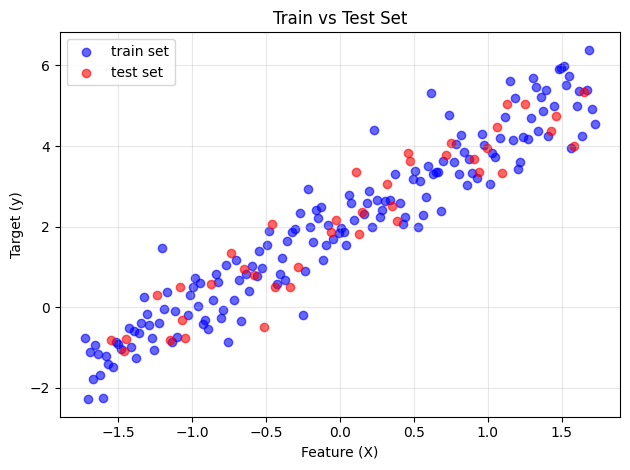

In [11]:
# Let's plot train set and test set
plt.scatter(X_train, y_train, c="blue", alpha=0.6, label="train set")
plt.scatter(X_test, y_test, c="red", alpha=0.6, label="test set")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Train vs Test Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Components of Linear Regression
## Hypothesis Function
The hypothesis function for univariate linear regression is a linear equation:
$$
h(x) = w_0 + w_1x
$$

Where:
- **$h(x)$**: Hypothesis function (prediction)
- **$w_0$**: Bias term (y-intercept)
- **$w_1$**: Weight (slope)
- **$x$**: Input feature

**Goal of Linear Regression**: To find the best values of **$w_0$** and **$w_1$** that minimize the difference between predicted values and actual values.

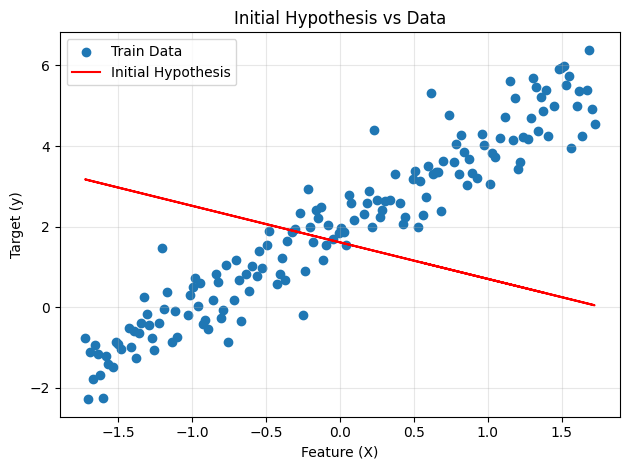

In [12]:
def hypothesis(X, w0, w1):
    return w0 + w1 * X


# Let's choose the initial values of w0 and w1
w0, w1 = np.random.randn(), np.random.randn()

# Now based on these parameters, let's calculate the predictions
predictions = hypothesis(X_train, w0, w1)
plt.scatter(X_train, y_train, label="Train Data")
plt.plot(X_train, predictions, color='red', label="Initial Hypothesis")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Initial Hypothesis vs Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cost Function

We use the **Mean Squared Error (MSE)** to quantify this difference, and call it cost:

$$
\text{cost} = J(w_0, w_1) = (1/2m) × \sum_{i=1}^{m} (h(x^i) - y^i)^2
$$

Where:
- **$m$**: Number of training examples
- **$h(x^i)$**: Prediction for i-th example
- **$y^i$**: Actual value for i-th example


In [13]:
def compute_cost(predictions, actual):
    m = len(actual)
    cost = (1 / (2 * m)) * np.sum((predictions - actual) ** 2)
    return cost

# Calculate the initial cost
initial_cost = compute_cost(predictions, y_train)
print(f"Current Parameters: w0 = {w0:.4f}, w1 = {w1:.4f}")
print(f"Initial Cost: {initial_cost:.4f}")

Current Parameters: w0 = 1.6124, w1 = -0.9061
Initial Cost: 4.6784


In [14]:
# Test with different parameters
test_params = [(0, 0), (1, 1), (2, 2), (3, 1)]
print(f"\nCost for different parameters:")
for w0, w1 in test_params:
    pred = hypothesis(w0, w1, X_train)
    cost = compute_cost(pred, y_train)
    print(f"w0 = {w0:}, w1 = {w1}\nCost = {cost:.4f}")



Cost for different parameters:
w0 = 0, w1 = 0
Cost = 4.3169
w0 = 1, w1 = 1
Cost = 1.2554
w0 = 2, w1 = 2
Cost = 0.1943
w0 = 3, w1 = 1
Cost = 1.2445


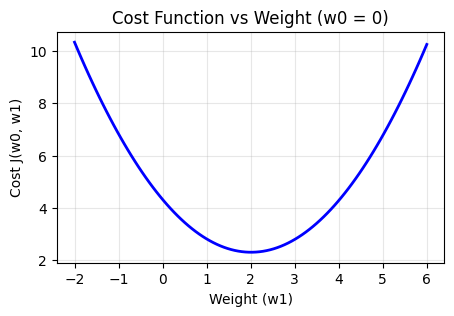

In [15]:

# Visualize cost function for different w1 values (keeping w0 = 0)
w1_range = np.linspace(-2, 6, 100)
predictions = [hypothesis(0, w1, X_train) for w1 in w1_range]
costs = [compute_cost(pred, y_train) for pred in predictions]

plt.figure(figsize=(5, 3))
plt.plot(w1_range, costs, 'b-', linewidth=2)
plt.xlabel('Weight (w1)')
plt.ylabel('Cost J(w0, w1)')
plt.title('Cost Function vs Weight (w0 = 0)')
plt.grid(True, alpha=0.3)
plt.show()


# Understanding Gradient Descent

## What is Gradient Descent?

**Gradient Descent** is an optimization algorithm used to minimize the cost function by iteratively adjusting the parameters in the direction of steepest descent.

## How Gradient Descent Works

1. **Start** with initial parameter values (w₀, w₁)
2. **Calculate** the gradient (partial derivatives)
3. **Update** parameters in the opposite direction of gradient
4. **Repeat** until convergence

# Mathematical Formulation

## Partial Derivatives:
$$∂J/∂w₀ = \frac{1}{m} \sum_{i=1}^{m} \left( h(x^{i}) - y^{i} \right)$$
$$∂J/∂w₁ = \frac{1}{m} \sum_{i=1}^{m} \left( h(x^{i}) - y^{i} \right) x^{i}$$


In [16]:
# Function 3: Gradient Calculation (Non-vectorized)
def compute_gradients(X, y, predictions):
    m = len(y)

    # Calculate gradients
    grad_w0 = (1 / m) * np.sum(predictions - y)
    grad_w1 = (1 / m) * np.sum((predictions - y) * X)

    return grad_w0, grad_w1


In [17]:
test_w0, test_w1 = 1, 2
pred = hypothesis(test_w0, test_w1, X_train)
grad_w0, grad_w1 = compute_gradients(pred, X_train, y_train)

print(f"Parameters: w0 = {test_w0}, w1 = {test_w1}")
print(f"Gradient w0: {grad_w0:.4f}")
print(f"Gradient w1: {grad_w1:.4f}")


Parameters: w0 = 1, w1 = 2
Gradient w0: 2.0255
Gradient w1: 5.0719


In [18]:
# Test with different parameters
test_params = [(0, 0), (1, 1), (2, 2), (3, 1)]
print(f"\nGradients for different parameters:")
for w0, w1 in test_params:
    pred = hypothesis(w0, w1, X_train)
    grad_w0, grad_w1 = compute_gradients(X_train, y_train, pred)
    print(f"w0 = {w0}, w1 = {w1} → grad_w0 = {grad_w0:.4f}, grad_w1 = {grad_w1:.4f}")



Gradients for different parameters:
w0 = 0, w1 = 0 → grad_w0 = -2.0106, grad_w1 = -2.0512
w0 = 1, w1 = 1 → grad_w0 = -1.0255, grad_w1 = -1.0358
w0 = 2, w1 = 2 → grad_w0 = -0.0404, grad_w1 = -0.0204
w0 = 3, w1 = 1 → grad_w0 = -1.0554, grad_w1 = 1.0250


## Parameter Updates:
$$
w_0 = w_0 - \alpha \frac{\partial J}{\partial w_0}
$$
$$
w_1 = w_1 - \alpha \frac{\partial J}{\partial w_1}
$$

Where $\alpha$ is the learning rate.

## Learning Rate Importance

- **Too small**: Slow convergence
- **Too large**: May overshoot the minimum
- **Just right**: Efficient convergence

In [19]:
def update_parameters(w0, w1, grad_w0, grad_w1, lr):

    new_w0 = w0 - lr * grad_w0
    new_w1 = w1 - lr * grad_w1
    
    return new_w0, new_w1


In [20]:
# Complete Gradient Descent Algorithm
def gradient_descent(
    X, y, learning_rate=0.01, num_iterations=1000, verbose=True
):
    # Initialize parameters
    w0, w1 = np.random.randn(), np.random.randn()
    m = len(X)

    # Store history for visualization
    cost_history = []
    w0_history = []
    w1_history = []

    if verbose:
        print(f"Starting Gradient Descent...")
        print(f"Learning rate: {learning_rate}")
        print(f"Number of iterations: {num_iterations}")
        print(f"Training examples: {m}")
        print("-" * 50)

    for i in range(num_iterations):
        # Calculate current cost
        pred = hypothesis(X, w0, w1)
        current_cost = compute_cost(pred, y)
        cost_history.append(current_cost)
        w0_history.append(w0)
        w1_history.append(w1)

        # Calculate gradients
        grad_w0, grad_w1 = compute_gradients(X, y, pred)

        # Update parameters
        w0, w1 = update_parameters(w0, w1, grad_w0, grad_w1, learning_rate)

        # Print progress every 100 iterations
        if verbose and (i + 1) % 10 == 0:
            print(
                f"Iteration {i+1:4d}: Cost = {current_cost:.6f}, w0 = {w0:.4f}, w1 = {w1:.4f}"
            )

    if verbose:
        print("-" * 50)
        print(f"Final parameters: w0 = {w0:.4f}, w1 = {w1:.4f}")
        print(f"Final cost: {cost_history[-1]:.6f}")

    return w0, w1, cost_history, w0_history, w1_history


In [21]:
w0_final, w1_final, cost_history, w0_history, w1_history = (
    gradient_descent(
        X_train, y_train, learning_rate=0.01, num_iterations=500
    )
)

print("Gradient descent completed successfully!")

Starting Gradient Descent...
Learning rate: 0.01
Number of iterations: 500
Training examples: 160
--------------------------------------------------
Iteration   10: Cost = 4.189963, w0 = 0.0578, w1 = 0.0453
Iteration   20: Cost = 3.461930, w0 = 0.2447, w1 = 0.2370
Iteration   30: Cost = 2.866541, w0 = 0.4140, w1 = 0.4100
Iteration   40: Cost = 2.379624, w0 = 0.5674, w1 = 0.5662
Iteration   50: Cost = 1.981412, w0 = 0.7063, w1 = 0.7073
Iteration   60: Cost = 1.655743, w0 = 0.8321, w1 = 0.8346
Iteration   70: Cost = 1.389399, w0 = 0.9460, w1 = 0.9497
Iteration   80: Cost = 1.171571, w0 = 1.0492, w1 = 1.0535
Iteration   90: Cost = 0.993420, w0 = 1.1427, w1 = 1.1473
Iteration  100: Cost = 0.847717, w0 = 1.2274, w1 = 1.2320
Iteration  110: Cost = 0.728551, w0 = 1.3041, w1 = 1.3084
Iteration  120: Cost = 0.631088, w0 = 1.3736, w1 = 1.3775
Iteration  130: Cost = 0.551375, w0 = 1.4365, w1 = 1.4398
Iteration  140: Cost = 0.486178, w0 = 1.4935, w1 = 1.4961
Iteration  150: Cost = 0.432854, w0 = 1

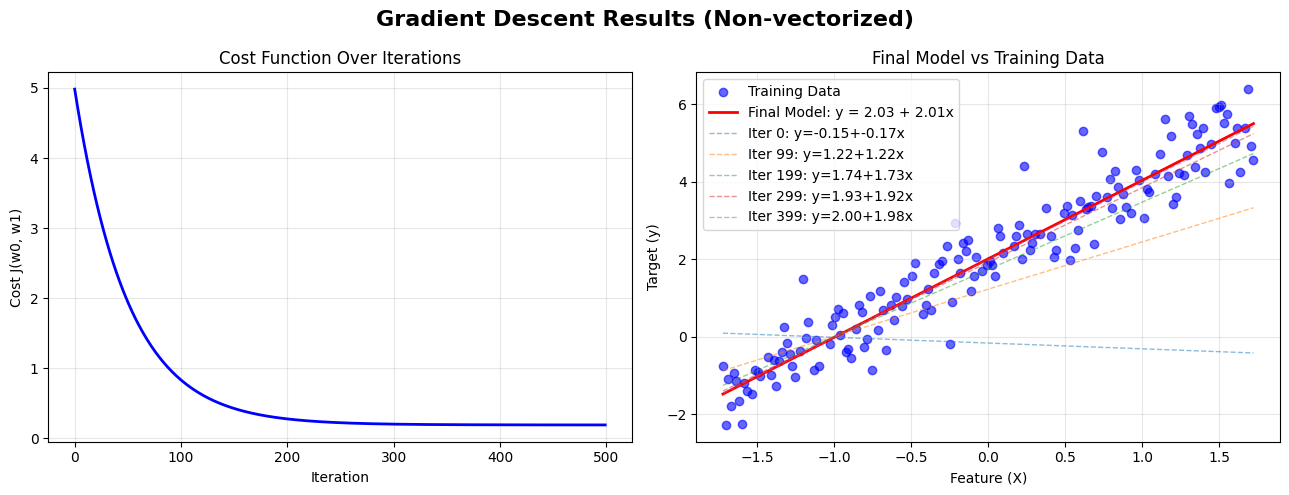

In [22]:
# Create comprehensive visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gradient Descent Results (Non-vectorized)', fontsize=16, fontweight='bold')

# Plot 1: Cost function over iterations
axes[0].plot(cost_history, 'b-', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost J(w0, w1)')
axes[0].set_title('Cost Function Over Iterations')
axes[0].grid(True, alpha=0.3)

# Plot 2: Final model vs data
x_range = np.linspace(X_train.min(), X_train.max(), 100)
y_pred = hypothesis(w0_final, w1_final, x_range)

axes[1].scatter(X_train, y_train, alpha=0.6, color='blue', label='Training Data')
axes[1].plot(x_range, y_pred, 'r-', linewidth=2, label=f'Final Model: y = {w0_final:.2f} + {w1_final:.2f}x')
# Plot 5 lines before the final weights are achieved
for idx in np.linspace(0, len(w0_history)-1, 6, dtype=int)[:-1]:
    y_pred_hist = hypothesis(w0_history[idx], w1_history[idx], x_range)
    axes[1].plot(x_range, y_pred_hist, '--', alpha=0.5, linewidth=1,
                 label=f'Iter {idx}: y={w0_history[idx]:.2f}+{w1_history[idx]:.2f}x')

axes[1].set_xlabel('Feature (X)')
axes[1].set_ylabel('Target (y)')
axes[1].set_title('Final Model vs Training Data')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [23]:

# Evaluate model performance
train_predictions = hypothesis(w0_final, w1_final, X_train)
test_predictions = hypothesis(w0_final, w1_final, X_test)

train_mse = np.mean((train_predictions - y_train) ** 2)
test_mse = np.mean((test_predictions - y_test) ** 2)

print(f"\nModel Performance:")
print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Final parameters: w0 = {w0_final:.4f}, w1 = {w1_final:.4f}")
print(f"Final cost: {cost_history[-1]:.6f}")



Model Performance:
Training MSE: 0.3877
Testing MSE: 0.3703
Final parameters: w0 = 2.0253, w1 = 2.0070
Final cost: 0.193498


# Vectorized Implementation

## Why Vectorization?

**Vectorization** uses matrix operations instead of loops, making computations much faster and more efficient.

## Mathematical Formulation (Vectorized)

### Matrix Notation:
$$
X = 
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_m
\end{bmatrix}
\quad (m \times 2 \text{ matrix})
$$

$$
\theta =
\begin{bmatrix}
w_0 \\
w_1
\end{bmatrix}
\quad (2 \times 1 \text{ vector})
$$

$$
y =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_m
\end{bmatrix}
\quad (m \times 1 \text{ vector})
$$

### Hypothesis (Vectorized):

$$
h(X) = X\theta
$$

### Cost Function (Vectorized):

$$
J(\theta) = \frac{1}{2m} (X\theta - y)^T (X\theta - y)
$$

### Gradients (Vectorized):

$$
\nabla J(\theta) = \frac{1}{m} X^T (X\theta - y)
$$

### Parameter Update (Vectorized):

$$
\theta = \theta - \alpha \nabla J(\theta)
$$


In [24]:
# Function 6: Prepare Data for Vectorized Operations
def prepare_data_vectorized(X):

    m = len(X)
    # Add bias column (column of ones)
    X = np.column_stack([np.ones(m), X])
    return X

# Test data preparation
X_train_vectorized = prepare_data_vectorized(X_train)
X_test_vectorized = prepare_data_vectorized(X_test)

print(f"Original X_train shape: {X_train.shape}")
print(f"Vectorized X_train shape: {X_train_vectorized.shape}")
print(f"First 5 rows of vectorized X_train:")
print(X_train_vectorized[:5])

Original X_train shape: (160, 1)
Vectorized X_train shape: (160, 2)
First 5 rows of vectorized X_train:
[[ 1.          0.56292355]
 [ 1.          1.16914891]
 [ 1.         -1.30771471]
 [ 1.          0.44167848]
 [ 1.          0.54560282]]


In [25]:
# Function 7: Vectorized Hypothesis Function
def hypothesis_vectorized(X, theta):
    pred = X @ theta
    return pred.reshape(-1, 1)


theta = np.array([1, 2])  # [w0, w1]
test_predictions = hypothesis_vectorized(X_train_vectorized, theta)

print(f"Parameters: theta = {theta}")
print(f"Predictions shape: {test_predictions.shape}")
print(f"First 5 predictions: {test_predictions[:5]}")

Parameters: theta = [1 2]
Predictions shape: (160, 1)
First 5 predictions: [[ 2.1258471 ]
 [ 3.33829782]
 [-1.61542941]
 [ 1.88335695]
 [ 2.09120565]]


In [26]:
# Function 8: Vectorized Cost Function
def cost_function_vectorized(predictions, actual):

    m = len(actual)
    cost = (1 / (2 * m)) * np.sum((predictions - actual) ** 2)
    return cost

# Test vectorized cost function
print("=== Testing Vectorized Cost Function ===")
theta = np.array([1, 2])
predictions = hypothesis_vectorized(X_train_vectorized, theta)
vectorized_cost = cost_function_vectorized(predictions, y_train)

print(f"Parameters: theta = {theta}")
print(f"Vectorized cost: {vectorized_cost:.6f}")



=== Testing Vectorized Cost Function ===
Parameters: theta = [1 2]
Vectorized cost: 0.734763


In [27]:
# Function 9: Vectorized Gradient Calculation
def compute_gradients_vectorized(X, pred, actual):

    m = len(actual)
    gradients = (1 / m) * X.T @ (pred - actual)
    return gradients.flatten()

theta = np.array([1, 2])
predictions = hypothesis_vectorized(X_train_vectorized, theta)
vectorized_gradients = compute_gradients_vectorized(X_train_vectorized, predictions, y_train)
print(f"Parameters: theta = {theta}")
print(f"Vectorized gradients: {vectorized_gradients}")


Parameters: theta = [1 2]
Vectorized gradients: [-1.04044539 -0.00541696]


In [28]:
def update_parameters_vectorized(theta, gradients, lr):
    new_theta = theta - lr * gradients
    return new_theta

In [29]:
# Function 10: Complete Vectorized Gradient Descent
def gradient_descent_vectorized(
    X, y, learning_rate=0.01, num_iterations=100, verbose=True
):

    # Initialize parameters
    theta = np.random.randn(2)  # [w0, w1]
    m = len(y)

    # Store history for visualization
    cost_history = []
    theta_history = []

    if verbose:
        print(f"Starting Vectorized Gradient Descent...")
        print(f"Learning rate: {learning_rate}")
        print(f"Number of iterations: {num_iterations}")
        print(f"Training examples: {m}")
        print("-" * 50)

    for i in range(num_iterations):
        # Calculate current cost
        pred = hypothesis_vectorized(X, theta)
        current_cost = cost_function_vectorized(pred, y)
        cost_history.append(current_cost)
        theta_history.append(theta.copy())

        # Calculate gradients
        gradients = compute_gradients_vectorized(X, pred, y)

        # Update parameters
        theta = update_parameters_vectorized(theta, gradients, learning_rate)

        # Print progress every 100 iterations
        if verbose and (i + 1) % 100 == 0:
            print(
                f"Iteration {i+1:4d}: Cost = {current_cost:.6f}, theta = [{theta[0]:.4f}, {theta[1]:.4f}]"
            )

    if verbose:
        print("-" * 50)
        print(f"Final parameters: theta = [{theta[0]:.4f}, {theta[1]:.4f}]")
        print(f"Final cost: {cost_history[-1]:.6f}")

    return theta, cost_history, theta_history


# Test vectorized gradient descent
print("=== Testing Vectorized Gradient Descent ===")
theta_final, cost_history_vec, theta_history_vec = gradient_descent_vectorized(
    X_train_vectorized, y_train, learning_rate=0.01, num_iterations=1000
)

print("Vectorized gradient descent completed successfully!")

=== Testing Vectorized Gradient Descent ===
Starting Vectorized Gradient Descent...
Learning rate: 0.01
Number of iterations: 1000
Training examples: 160
--------------------------------------------------
Iteration  100: Cost = 0.518092, theta = [1.7289, 1.2924]
Iteration  200: Cost = 0.235516, theta = [1.9226, 1.7602]
Iteration  300: Cost = 0.198787, theta = [1.9961, 1.9274]
Iteration  400: Cost = 0.194004, theta = [2.0239, 1.9871]
Iteration  500: Cost = 0.193380, theta = [2.0344, 2.0084]
Iteration  600: Cost = 0.193299, theta = [2.0384, 2.0161]
Iteration  700: Cost = 0.193288, theta = [2.0399, 2.0188]
Iteration  800: Cost = 0.193286, theta = [2.0404, 2.0198]
Iteration  900: Cost = 0.193286, theta = [2.0406, 2.0202]
Iteration 1000: Cost = 0.193286, theta = [2.0407, 2.0203]
--------------------------------------------------
Final parameters: theta = [2.0407, 2.0203]
Final cost: 0.193286
Vectorized gradient descent completed successfully!


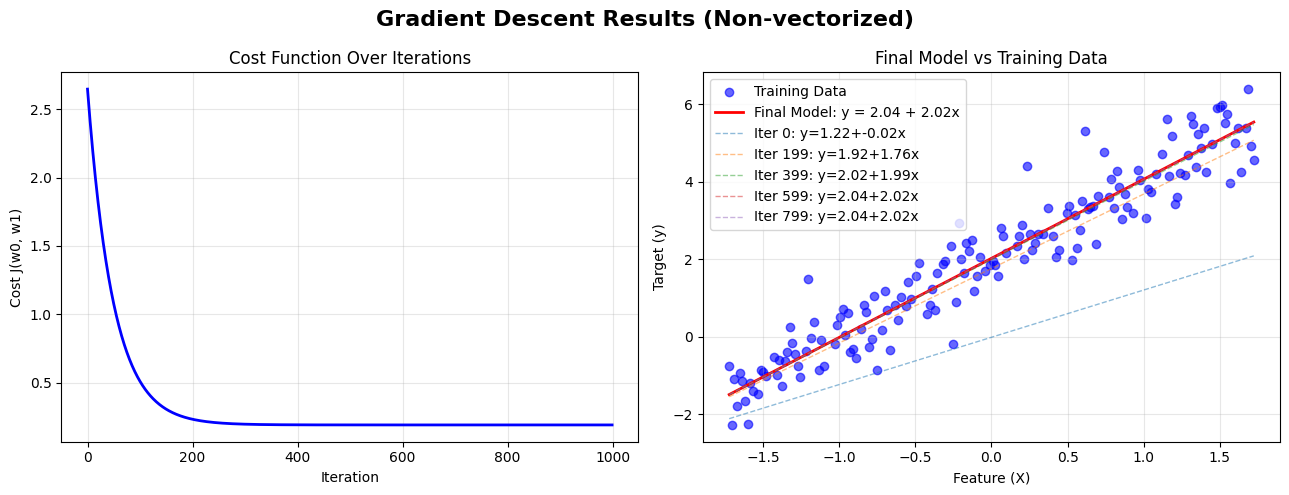

In [30]:
# Create comprehensive visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Gradient Descent Results (Non-vectorized)", fontsize=16, fontweight="bold"
)

# Plot 1: Cost function over iterations
axes[0].plot(cost_history_vec, "b-", linewidth=2)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Cost J(w0, w1)")
axes[0].set_title("Cost Function Over Iterations")
axes[0].grid(True, alpha=0.3)

# Plot 2: Final model vs data
x_range = np.linspace(X_train.min(), X_train.max(), 100)
y_pred = hypothesis(theta_final[0], theta_final[1], x_range)

axes[1].scatter(X_train, y_train, alpha=0.6, color="blue", label="Training Data")
axes[1].plot(
    x_range,
    y_pred,
    "r-",
    linewidth=2,
    label=f"Final Model: y = {theta_final[0]:.2f} + {theta_final[1]:.2f}x",
)
# Plot 5 lines before the final weights are achieved
for idx in np.linspace(0, len(theta_history_vec) - 1, 6, dtype=int)[:-1]:
    y_pred_hist = hypothesis(theta_history_vec[idx][0], theta_history_vec[idx][1], x_range)
    axes[1].plot(
        x_range,
        y_pred_hist,
        "--",
        alpha=0.5,
        linewidth=1,
        label=f"Iter {idx}: y={theta_history_vec[idx][0]:.2f}+{theta_history_vec[idx][1]:.2f}x",
    )

axes[1].set_xlabel("Feature (X)")
axes[1].set_ylabel("Target (y)")
axes[1].set_title("Final Model vs Training Data")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# Evaluate the trained linear regression model on the test set
test_set_predictions = hypothesis(theta_final[0], theta_final[1], X_test)
test_set_mse = np.mean((test_set_predictions - y_test) ** 2)

print(f"Test set MSE: {test_set_mse:.4f}")
print(f"Trained parameters: w0 = {theta_final[0]:.4f}, w1 = {theta_final[1]:.4f}")

Test set MSE: 0.3725
Trained parameters: w0 = 2.0407, w1 = 2.0203
